In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #Estandariza los datos.
from sklearn.linear_model import LinearRegression #Importo el modelo.
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

1. Linear regression for gallons. If the lienar regression in api-zonar-1 is different,the reason is that its model works in Liters. Dividing the slope and intercept with 3.785412 as divider, slope and intercept are very similar.

In [68]:
df_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\TRACTOR 65 GL 245071.xlsx')
df_data.info()

df_data['NCode']=df_data['Measured']
df_data['Volume']=df_data['User']

#df_data.to_csv('/home/jlhb1984/py-projects/data/cases/Export.csv')

x=df_data['NCode'].values.reshape(-1, 1)#Si no se pone, sale error porque x_std y y_std requieren este reshape.
y=df_data['Volume'].values.reshape(-1, 1)
sc_x=StandardScaler()
sc_y=StandardScaler()
x_std=sc_x.fit_transform(x)
y_std=sc_y.fit_transform(y)
slr=LinearRegression()
slr.fit(x_std,y_std)

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   User         14 non-null     int64         
 1   Measured     14 non-null     int64         
 2   Date         14 non-null     datetime64[us]
 3   Temperature  14 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 580.0 bytes


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
X_cols=df_data['NCode'].values.reshape(-1,1)
y_col=df_data['Volume'].values.reshape(-1,1)

X=X_cols
y=y_col

X_train, X_test, y_train, y_test = train_test_split(X,y)
sc_x=StandardScaler().fit(X)
sc_y=StandardScaler().fit(y)

X_train=sc_x.transform(X_train)
X_test=sc_x.transform(X_test)
y_train=sc_y.transform(y_train)
y_test=sc_y.transform(y_test)

model=LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [70]:
#print('X_train,y_train:\n',X_train,y_train,'\n','X_test,y_test:\n',X_train,y_test)

In [71]:
model = LinearRegression()
model.fit(X, y)

# 3. Access the Slope and Intercept
slope = model.coef_
intercept = model.intercept_

print(f"Slope (Coefficient): {slope}")
print(f"Intercept: {intercept}")

Slope (Coefficient): [[0.01717474]]
Intercept: [2.81469659]


Text(0.5, 0, 'N code')

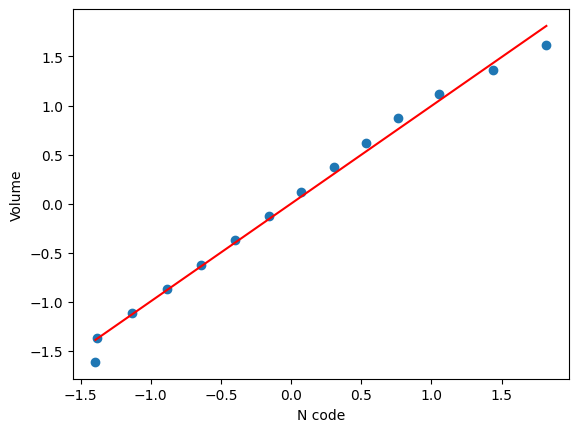

In [72]:
plt.scatter(x_std,y_std)
plt.plot(x_std,slr.predict(x_std),color='red')
plt.ylabel('Volume')
plt.xlabel('N code')

c:\Users\Jose.Hurtado\Documents\Zonar_projects\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


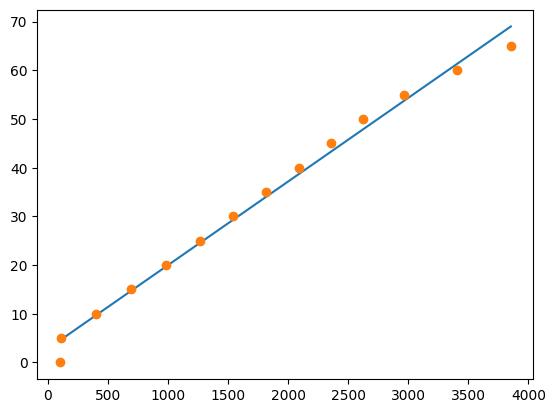

In [73]:
X1=df_data[["Measured"]]
y1=df_data["User"]*3.78541    
model1= LinearRegression()
model1.fit(X, y)

plt.plot(X1, model1.predict(X1), '-', label='Regression line')
plt.plot(X, y, 'o', label='Data points')


In [74]:
mse = metrics.mean_squared_error(y_test,y_pred)
r2 = metrics.r2_score(y_test, y_pred)

#print("r2 ", r2.round(4))
#print("mse: ", mse.round(4))
print("r2 ", r2)
print("mse: ", mse)

r2  0.9831990730322385
mse:  0.005880324438716525


In [75]:
ncode=input("N Code: ")
num_galons_lr=sc_x.transform(np.array([ncode]).reshape(-1,1))
sc_y.inverse_transform(slr.predict(num_galons_lr))

array([[19.97225728]])

Polynomial regression

In [76]:
# 1. Sample data
X_poly=df_data['Measured'].values.reshape(-1,1)
y_poly=df_data['User'].values.reshape(-1,1)

# 2. Build a polynomial model (e.g., degree 2)
degree=2
model=make_pipeline(PolynomialFeatures(degree), LinearRegression())

# 3. Fit and predict
model.fit(X_poly, y_poly)
predictions= model.predict(np.array([ncode]).reshape(-1,1))  # Output: ~36.0
print("Predicted value for: ",ncode,predictions)

linear_step = model.named_steps['linearregression']
c = linear_step.intercept_
coefs = linear_step.coef_

# coefs corresponds to [1, x, x^2] (or [x, x^2] depending on include_bias)
# By default, PolynomialFeatures includes a bias term (degree 0), so coef_[0] = 0

print("Polynomial model: ",c,coefs)

Predicted value for:  999 [[20.76003659]]
Polynomial model:  [0.34289215] [[ 0.00000000e+00  2.16429152e-02 -1.20653968e-06]]


Text(0.5, 0, 'N code')

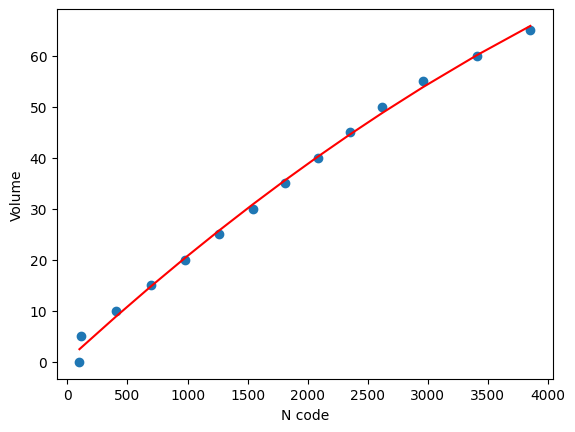

In [77]:
plt.scatter(X_poly,y_poly)
plt.plot(X_poly,model.predict(X_poly),color='red')
plt.ylabel('Volume')
plt.xlabel('N code')

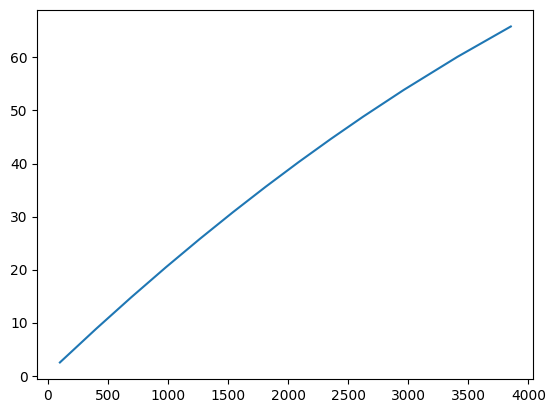

In [78]:
y_plot=[]
x_plot=[]
for i in range(0,df_data.shape[0]):
    x_plot.append(df_data.iloc[i,4])
    y=2.16429152e-02*(df_data.iloc[i,4])-1.20653968e-06*(df_data.iloc[i,4]**2)+0.34289215
    y_plot.append(y)

plt.plot(x_plot,y_plot)